In [1]:
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pandas as pd

In [2]:
#Active Model:

In [3]:
runs_eval_path = '/vision/asomaya1/active-rir/runs'
stats_file_name = 'test_telephone_stats_0.json'

# Specify models to run
runs = ['SD_CNA_all_subg_queries', 'SD_C_all_subg_queries']  # Add your model names here

# Load scene sizes (if needed for the calculations, otherwise ignore)
with open("/vision/asomaya1/active-rir/data/metadata/scene_sizes.json", "rb") as f:
    scene_sizes = json.load(f)

In [4]:
# Initialize dictionary to store metrics for each model
all_models_metrics = {}

for run in runs:
    full_path = os.path.join(runs_eval_path, run, "tb", stats_file_name)

    # Open and load the JSON file
    with open(full_path, 'r') as json_file:
        data = json.load(json_file)

    # Dictionary to store aggregated metrics for each scene
    scene_metrics = {}

    # Iterate through the dictionary and group metrics by scene
    for key, metrics in data.items():
        # Split the key to extract the scene name
        parts = key.split('/')
        scene_name = parts[3]  # Assuming the scene name is always in the fourth position
        if scene_name not in scene_metrics:
            scene_metrics[scene_name] = {key: [] for key in metrics.keys()}
        # Append metrics to the scene-specific list
        for metric_key in metrics:
            scene_metrics[scene_name][metric_key].append(metrics[metric_key])

    # Store the aggregated metrics for the current model
    all_models_metrics[run] = scene_metrics

# Now, calculate average and standard error metrics for each model and scene
final_data = {'model': [], 'scene': [], 'metric': [], 'average': [], 'stderr': []}

for model, scenes in all_models_metrics.items():
    for scene_name, metrics in scenes.items():
        for metric_name, values in metrics.items():
            final_data['model'].append(model)
            final_data['scene'].append(scene_name)
            final_data['metric'].append(metric_name)
            final_data['average'].append(np.mean(values))
            final_data['stderr'].append(np.std(values) / np.sqrt(len(values)))

# Convert to DataFrame
df = pd.DataFrame(final_data)

# Pivot the DataFrame to get the desired MultiIndex format
# Assuming 'metric' as columns, 'model' and 'scene' as a MultiIndex for rows
df_pivoted = df.pivot_table(index=['model', 'scene'], columns='metric', values='average', aggfunc='first')

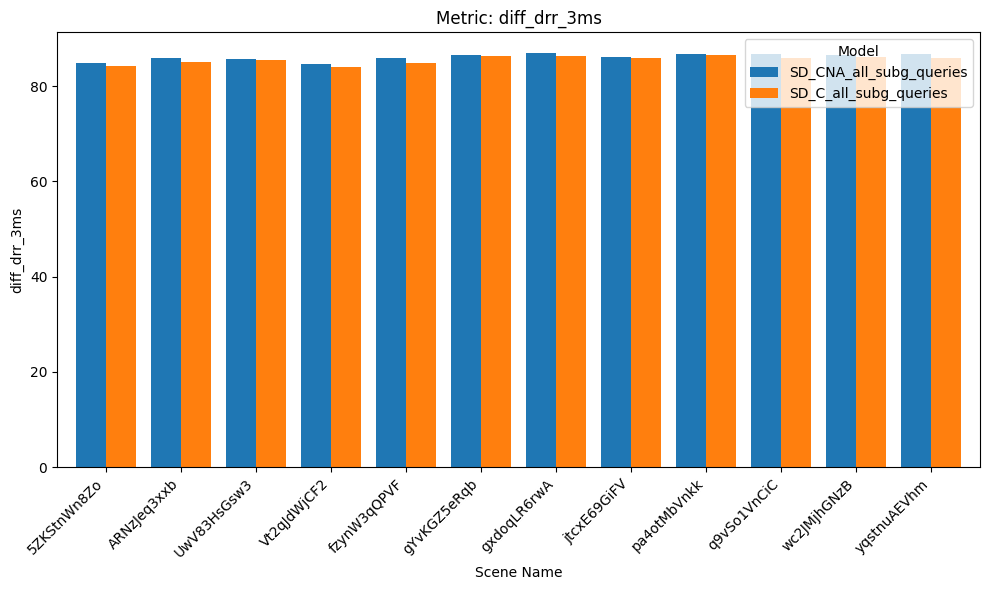

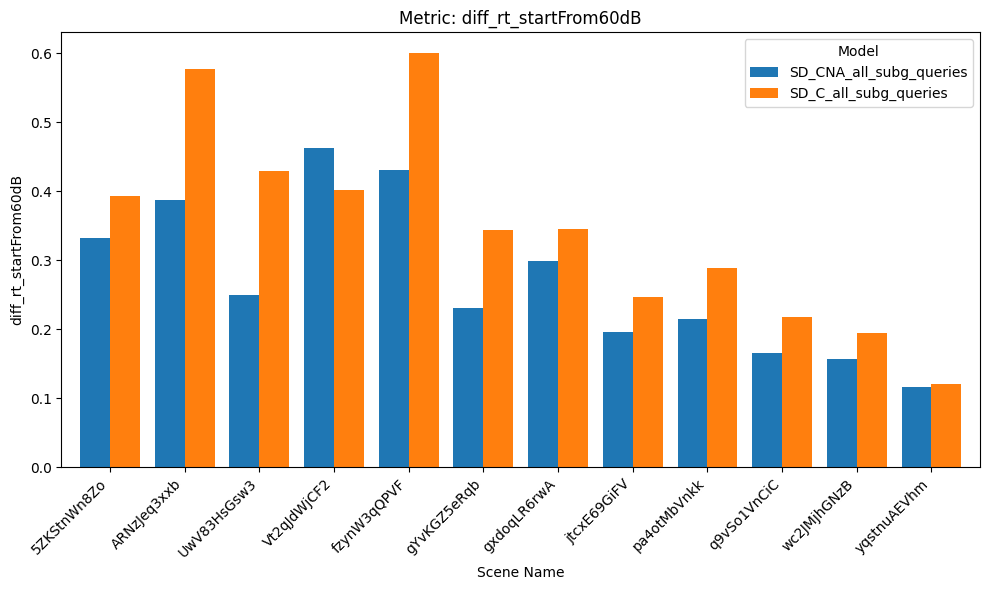

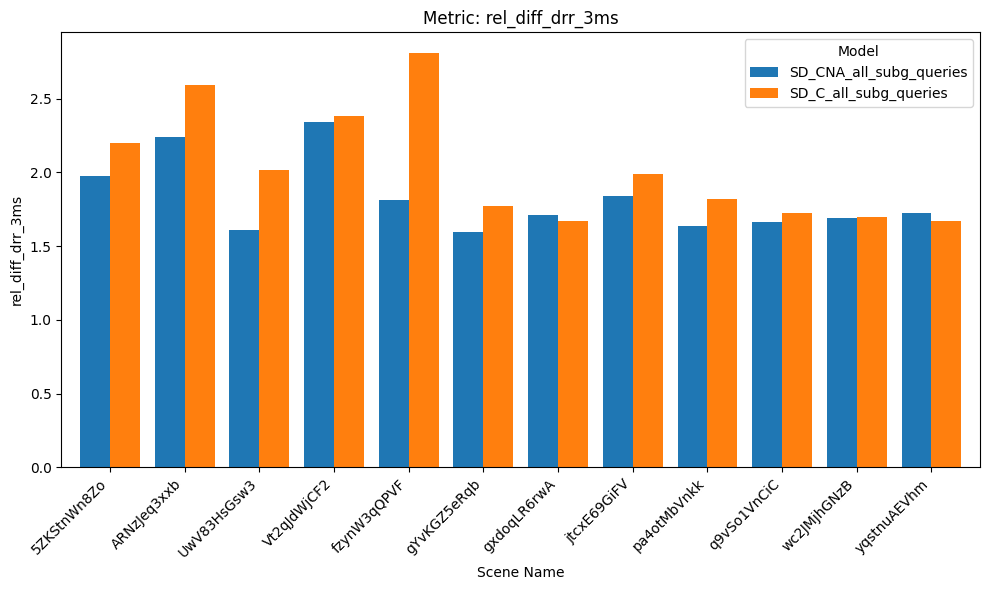

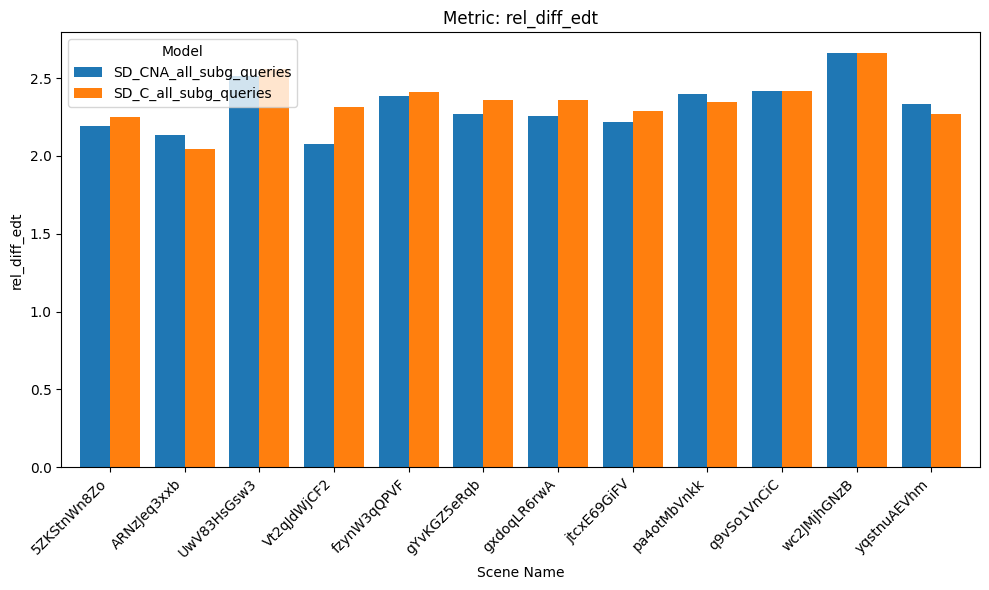

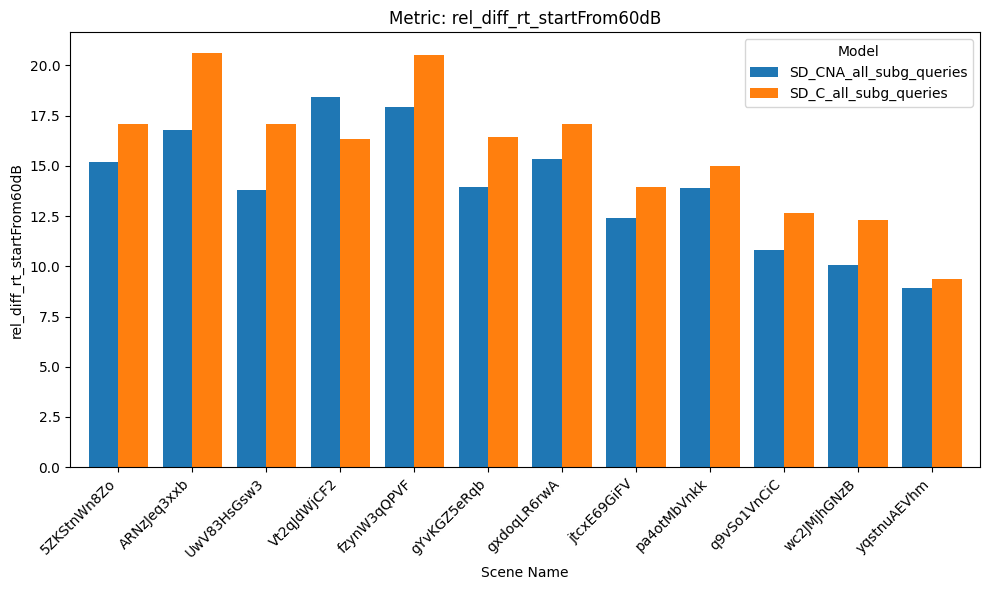

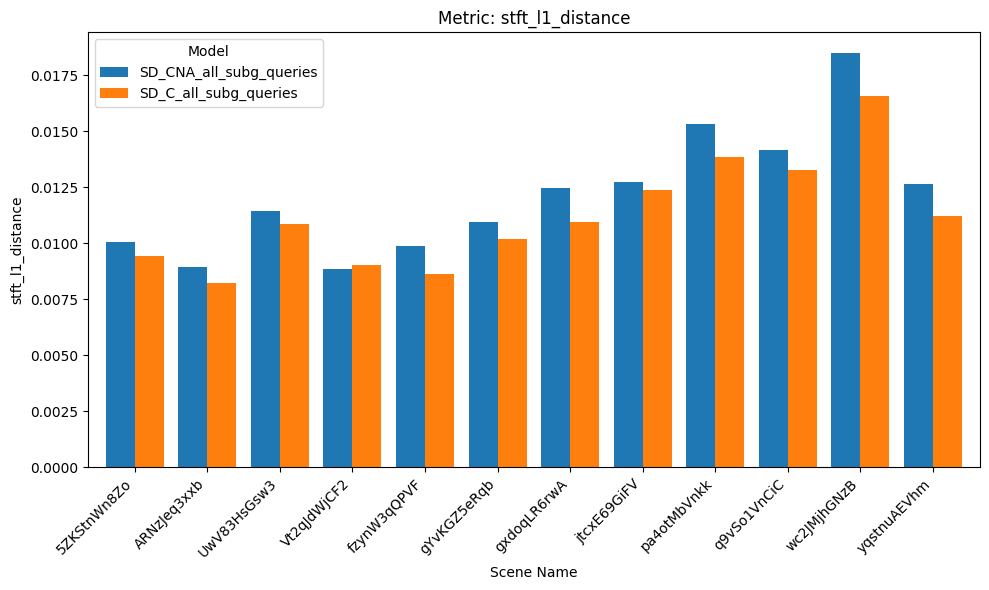

In [5]:
import matplotlib.pyplot as plt

# Assuming df_pivoted is your DataFrame
# Unstack the 'model' level of the MultiIndex to get models as columns
df_unstacked = df_pivoted.unstack(level='model')

# Plotting
for metric in df_unstacked.columns.levels[0]:  # Iterate through each metric
    if "reward" in metric:
        continue
    fig, ax = plt.subplots(figsize=(10, 6))  # Adjust the figure size as needed
    df_unstacked[metric].plot(kind='bar', ax=ax, width=0.8)  # Plot a bar graph for the current metric
    ax.set_title(f'Metric: {metric}')  # Set the title to the current metric
    ax.set_xlabel('Scene Name')  # X-axis label
    ax.set_ylabel(metric)  # Y-axis label, dynamically use the metric name
    ax.legend(title='Model')  # Add a legend with a title
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
    plt.tight_layout()  # Adjust layout to not cut off labels
    plt.show()  # Display the plot

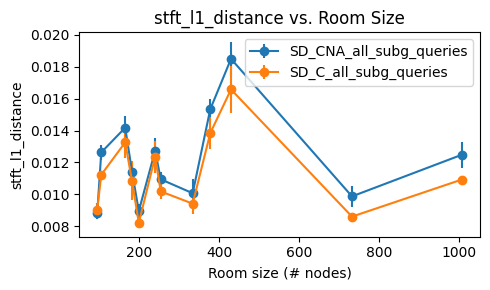

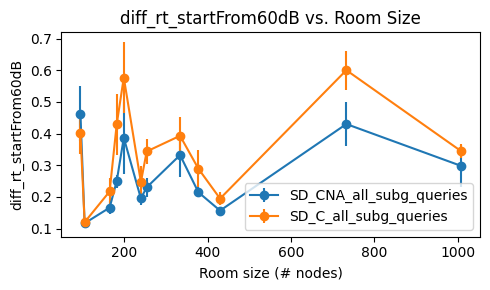

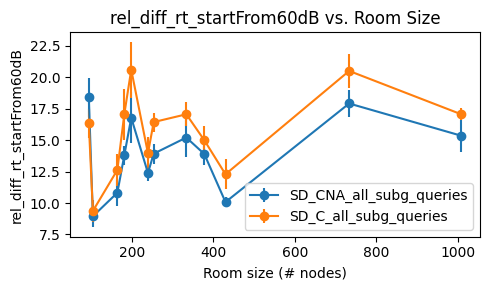

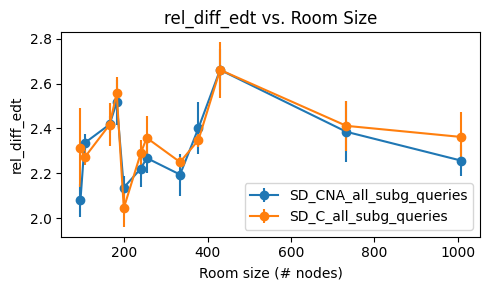

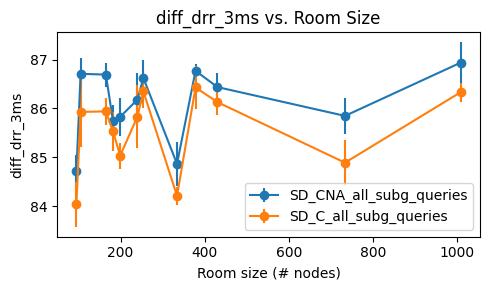

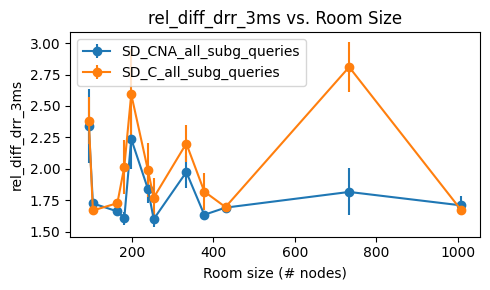

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'df' is your DataFrame containing model, scene, metric, average, and stderr columns
# First, ensure df is ready for plotting as needed

# Plotting each metric as a function of scene size, for each model
metrics_to_plot = df['metric'].unique()  # Assuming this gets all unique metrics you want to plot

for metric in metrics_to_plot:
    if "reward" in metric:
        continue
    plt.figure(figsize=(5, 3))  # Adjust the figsize if needed

    # Loop through each model to plot on the same graph
    for model in df['model'].unique():
        model_df = df[(df['metric'] == metric) & (df['model'] == model)]

        # Extract scene sizes, metric values, and standard errors
        # Assuming 'scene' matches keys in 'scene_sizes' to get room sizes
        integers = [scene_sizes[scene] for scene in model_df['scene']]
        metric_values = model_df['average'].tolist()
        stderr_values = model_df['stderr'].tolist()

        # Sort data by scene size
        sorted_data = sorted(zip(integers, metric_values, stderr_values), key=lambda x: x[0])
        sorted_integers, sorted_metric_values, sorted_stderr_values = zip(*sorted_data)

        # Plot for the current model
        plt.errorbar(sorted_integers, sorted_metric_values, yerr=sorted_stderr_values,
                     linestyle='-', marker='o', label=model)

    plt.xlabel('Room size (# nodes)')
    plt.ylabel(metric)
    plt.title(f'{metric} vs. Room Size')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [7]:
from collections import defaultdict
import itertools
import numpy as np
import pandas as pd

# Initialize three defaultdicts for mean, median, and std
mean_results = defaultdict(dict)
median_results = defaultdict(dict)
std_results = defaultdict(dict)
round_val = 8

for model_name, run in all_models_metrics.items():
    for metric in run[list(run.keys())[0]].keys():
        if metric == "reward":
            continue
        # Flatten the list of lists for the current metric across all runs
        values = list(itertools.chain.from_iterable([inner_dict[metric] for inner_dict in run.values()]))
        # Calculate mean, median, and std
        mean_val = np.round(np.mean(values), round_val)
        median_val = np.round(np.median(values), round_val)
        std_val = np.round(np.std(values), round_val)
        
        # Populate the defaultdicts
        mean_results[model_name][metric] = mean_val
        median_results[model_name][metric] = median_val
        std_results[model_name][metric] = std_val

# Convert the defaultdicts to pandas DataFrames
df_mean = pd.DataFrame(mean_results)
df_median = pd.DataFrame(median_results)
df_std = pd.DataFrame(std_results)

# Display the DataFrames
print("Means aggregated across all test episodes:")
df_mean.T

Means aggregated across all test episodes:


,stft_l1_distance,diff_rt_startFrom60dB,rel_diff_rt_startFrom60dB,rel_diff_edt,diff_drr_3ms,rel_diff_drr_3ms
SD_CNA_all_subg_queries,0.012131,0.279610,14.257327,2.323901,86.078620,1.824357
SD_C_all_subg_queries,0.011189,0.360534,16.064786,2.363097,85.527898,2.048547


In [8]:
print("\nMedians aggregated across all test episodes:")
df_median.T


Medians aggregated across all test episodes:


,stft_l1_distance,diff_rt_startFrom60dB,rel_diff_rt_startFrom60dB,rel_diff_edt,diff_drr_3ms,rel_diff_drr_3ms
SD_CNA_all_subg_queries,0.011725,0.225147,14.128534,2.294605,86.317025,1.684392
SD_C_all_subg_queries,0.010505,0.302049,15.756964,2.318014,85.534930,1.751052


In [9]:
print("\nSTDs aggregated across all test episodes:")
df_std.T


STDs aggregated across all test episodes:


,stft_l1_distance,diff_rt_startFrom60dB,rel_diff_rt_startFrom60dB,rel_diff_edt,diff_drr_3ms,rel_diff_drr_3ms
SD_CNA_all_subg_queries,0.003195,0.164828,3.768779,0.252104,1.065198,0.394383
SD_C_all_subg_queries,0.003018,0.193007,4.113117,0.265308,1.161597,0.547234


In [10]:
#********************************************************************************FS-RIR MODEL********************************************************************************

In [11]:
active_test_scene_names = """5ZKStnWn8Zo
ARNzJeq3xxb
fzynW3qQPVF
gxdoqLR6rwA
gYvKGZ5eRqb
jtcxE69GiFV
pa4otMbVnkk
q9vSo1VnCiC
UwV83HsGsw3
Vt2qJdWjCF2
wc2JMjhGNzB
yqstnuAEVhm"""

# Split the data into a list of strings
active_test_scene_names = active_test_scene_names.split('\n')

In [12]:
test_scene_episode_counts_1000 = """
2023-10-11 16:53:30, INFO: Sampled 19 from 5ZKStnWn8Zo
2023-10-11 16:53:30, INFO: Sampled 10 from ARNzJeq3xxb
2023-10-11 16:53:31, INFO: Sampled 5 from UwV83HsGsw3
2023-10-11 16:53:31, INFO: Sampled 6 from Vt2qJdWjCF2
2023-10-11 16:53:31, INFO: Sampled 390 from fzynW3qQPVF
2023-10-11 16:53:31, INFO: Sampled 38 from gYvKGZ5eRqb
2023-10-11 16:53:31, INFO: Sampled 449 from gxdoqLR6rwA
2023-10-11 16:53:31, INFO: Sampled 4 from jtcxE69GiFV
2023-10-11 16:53:31, INFO: Sampled 34 from pa4otMbVnkk
2023-10-11 16:53:31, INFO: Sampled 17 from q9vSo1VnCiC
2023-10-11 16:53:31, INFO: Sampled 26 from wc2JMjhGNzB
2023-10-11 16:53:31, INFO: Sampled 2 from yqstnuAEVhm
"""

test_scene_episode_counts = """
2023-10-11 16:53:30, INFO: Sampled 19 from 5ZKStnWn8Zo
2023-10-11 16:53:30, INFO: Sampled 10 from ARNzJeq3xxb
2023-10-11 16:53:31, INFO: Sampled 5 from UwV83HsGsw3
2023-10-11 16:53:31, INFO: Sampled 6 from Vt2qJdWjCF2
2023-10-11 16:53:31, INFO: Sampled 326 from fzynW3qQPVF
2023-10-11 16:53:31, INFO: Sampled 38 from gYvKGZ5eRqb
2023-10-11 16:53:31, INFO: Sampled 213 from gxdoqLR6rwA
2023-10-11 16:53:31, INFO: Sampled 4 from jtcxE69GiFV
2023-10-11 16:53:31, INFO: Sampled 34 from pa4otMbVnkk
2023-10-11 16:53:31, INFO: Sampled 17 from q9vSo1VnCiC
2023-10-11 16:53:31, INFO: Sampled 26 from wc2JMjhGNzB
2023-10-11 16:53:31, INFO: Sampled 2 from yqstnuAEVhm
"""


test_scene_episode_counts_5k = """
2023-11-01 00:04:22, INFO: Sampled 19 from 5ZKStnWn8Zo                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 10 from ARNzJeq3xxb                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 5 from UwV83HsGsw3                                                                                                                               
2023-11-01 00:04:22, INFO: Sampled 6 from Vt2qJdWjCF2                                                                                                                               
2023-11-01 00:04:22, INFO: Sampled 50 from fzynW3qQPVF                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 38 from gYvKGZ5eRqb                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 50 from gxdoqLR6rwA                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 4 from jtcxE69GiFV                                                                                                                               
2023-11-01 00:04:22, INFO: Sampled 34 from pa4otMbVnkk                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 17 from q9vSo1VnCiC                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 26 from wc2JMjhGNzB                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 2 from yqstnuAEVhm 
"""

test_scene_episode_counts_5 = """
2023-11-01 00:04:22, INFO: Sampled 5 from 5ZKStnWn8Zo                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 5 from ARNzJeq3xxb                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 5 from UwV83HsGsw3                                                                                                                               
2023-11-01 00:04:22, INFO: Sampled 5 from Vt2qJdWjCF2                                                                                                                               
2023-11-01 00:04:22, INFO: Sampled 5 from fzynW3qQPVF                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 5 from gYvKGZ5eRqb                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 5 from gxdoqLR6rwA                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 4 from jtcxE69GiFV                                                                                                                               
2023-11-01 00:04:22, INFO: Sampled 5 from pa4otMbVnkk                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 5 from q9vSo1VnCiC                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 5 from wc2JMjhGNzB                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 2 from yqstnuAEVhm 
"""

test_scene_episode_counts_2 = """
2023-11-01 00:04:22, INFO: Sampled 2 from 5ZKStnWn8Zo                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 2 from ARNzJeq3xxb                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 0 from UwV83HsGsw3                                                                                                                               
2023-11-01 00:04:22, INFO: Sampled 2 from Vt2qJdWjCF2                                                                                                                               
2023-11-01 00:04:22, INFO: Sampled 2 from fzynW3qQPVF                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 2 from gYvKGZ5eRqb                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 0 from gxdoqLR6rwA                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 2 from jtcxE69GiFV                                                                                                                               
2023-11-01 00:04:22, INFO: Sampled 2 from pa4otMbVnkk                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 2 from q9vSo1VnCiC                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 2 from wc2JMjhGNzB                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 2 from yqstnuAEVhm 
"""

test_scene_episode_counts_225 = """
2024-02-18 16:18:39, INFO: Sampled 19 from 5ZKStnWn8Zo                                                                                                                                                                                         
2024-02-18 16:18:39, INFO: Sampled 10 from ARNzJeq3xxb                                                                                                                                                                                         
2024-02-18 16:18:39, INFO: Sampled 5 from UwV83HsGsw3                                                                                                                                                                                          
2024-02-18 16:18:39, INFO: Sampled 6 from Vt2qJdWjCF2                                                                                                                                                                                          
2024-02-18 16:18:39, INFO: Sampled 34 from fzynW3qQPVF                                                                                                                                                                                         
2024-02-18 16:18:39, INFO: Sampled 34 from gYvKGZ5eRqb                                                                                                                                                                                         
2024-02-18 16:18:39, INFO: Sampled 34 from gxdoqLR6rwA                                                                                                                                                                                         
2024-02-18 16:18:39, INFO: Sampled 4 from jtcxE69GiFV                                                                                                                                                                                          
2024-02-18 16:18:39, INFO: Sampled 34 from pa4otMbVnkk                                                                                                                                                                                         
2024-02-18 16:18:39, INFO: Sampled 17 from q9vSo1VnCiC                                                                                                                                                                                         
2024-02-18 16:18:39, INFO: Sampled 26 from wc2JMjhGNzB                                                                                                                                                                                         
2024-02-18 16:18:39, INFO: Sampled 2 from yqstnuAEVhm
"""

# Split the data into lines
lines = test_scene_episode_counts_225.strip().split('\n')

# Create a dictionary to store the mappings
test_scene_episode_counts_dict = {}

# Iterate through each line and extract the number sampled and the string
for line in lines:
    parts = line.split('from ')
    if len(parts) == 2:
        number_sampled = int(parts[0].split()[-1].strip())
        string_after_from = parts[1].strip()
        test_scene_episode_counts_dict[string_after_from] = number_sampled

# Print the resulting dictionary
print(test_scene_episode_counts_dict)

{'5ZKStnWn8Zo': 19, 'ARNzJeq3xxb': 10, 'UwV83HsGsw3': 5, 'Vt2qJdWjCF2': 6, 'fzynW3qQPVF': 34, 'gYvKGZ5eRqb': 34, 'gxdoqLR6rwA': 34, 'jtcxE69GiFV': 4, 'pa4otMbVnkk': 34, 'q9vSo1VnCiC': 17, 'wc2JMjhGNzB': 26, 'yqstnuAEVhm': 2}


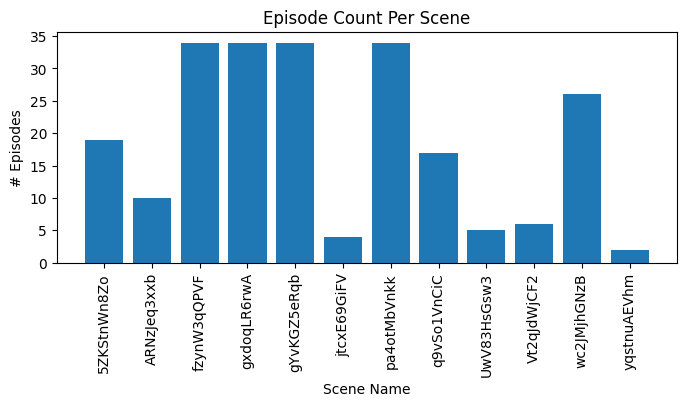

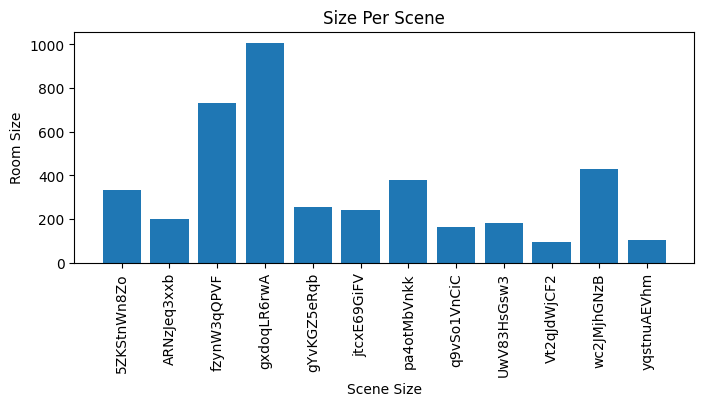

In [13]:
scenes_to_eval = active_test_scene_names
#keys = list(test_scene_episode_counts_dict.keys())
values = [test_scene_episode_counts_dict[key] for key in scenes_to_eval]
scene_size_values = [scene_sizes[key] for key in scenes_to_eval]

# Create the bar plot
plt.figure(figsize=(8, 3))  # You can adjust the figure size as needed
plt.bar(scenes_to_eval, values)
plt.xlabel('Scene Name')
plt.ylabel('# Episodes')
plt.title('Episode Count Per Scene')
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility

plt.show()

# Create the bar plot
plt.figure(figsize=(8, 3))  # You can adjust the figure size as needed
plt.bar(scenes_to_eval, scene_size_values)
plt.xlabel('Scene Size')
plt.ylabel('Room Size')
plt.title('Size Per Scene')
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility

plt.show()


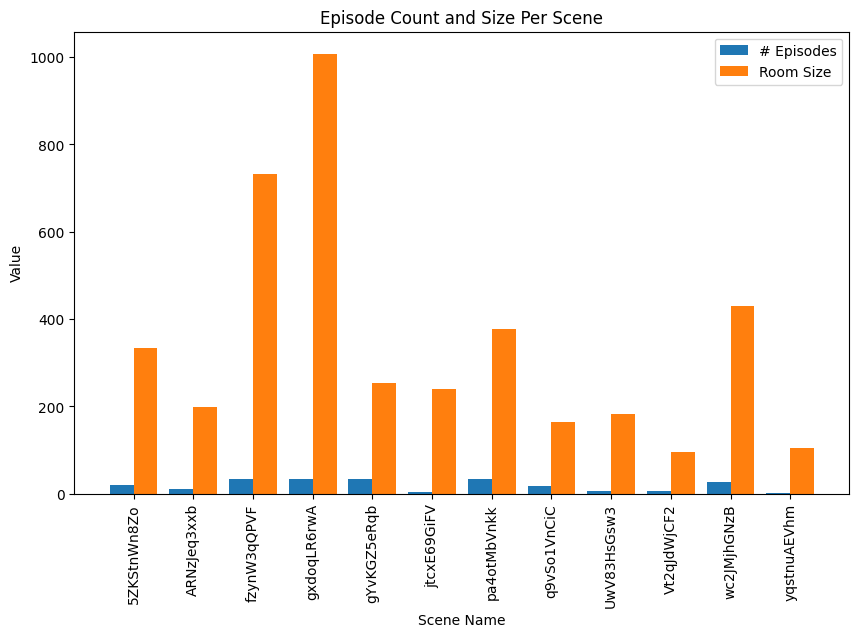

In [14]:
import matplotlib.pyplot as plt
import numpy as np

scenes_to_eval = active_test_scene_names
values = [test_scene_episode_counts_dict[key] for key in scenes_to_eval]
scene_size_values = [scene_sizes[key] for key in scenes_to_eval]

# Set up the figure and axis
plt.figure(figsize=(10, 6))  # Adjusted for better visibility and to accommodate both bars

# Set the positions and width for the bars
positions = np.arange(len(scenes_to_eval))  # Positions for the first set of bars
width = 0.4  # Width of the bars, adjust as needed for aesthetics

# Plotting both sets of bars
plt.bar(positions - width/2, values, width=width, label='# Episodes')
plt.bar(positions + width/2, scene_size_values, width=width, label='Room Size')

# Adding labels, title, and legend
plt.xlabel('Scene Name')
plt.ylabel('Value')
plt.title('Episode Count and Size Per Scene')
plt.xticks(positions, scenes_to_eval, rotation=90)  # Assign scene names to x-axis positions
plt.legend()

# Display the plot
plt.show()

In [15]:
dir_path = "/vision/asomaya1/active-rir/runs_eval/fs_rir"

with open(os.path.join(dir_path, "unseen_eval_364datapoints_metrics.pkl"), "rb") as f:
    metric_data = pickle.load(f)

with open(os.path.join(dir_path, "unseen_eval_364datapoints_sceneNames.pkl"), "rb") as f:
    scene_names = pickle.load(f)

with open("/vision/asomaya1/active-rir/data/metadata/scene_sizes.json", "rb") as f:
    scene_to_room_size = json.load(f)

In [16]:
from collections import defaultdict

scene_statistics = {}
active_metric_data = defaultdict(list)
# Iterate through unique scene names in your_scene_names
for scene_name in set(scene_names):
    if scene_name in active_test_scene_names:
        scene_indices = [i for i, name in enumerate(scene_names) if name == scene_name][:test_scene_episode_counts_dict[scene_name]]
    else:
        scene_indices = [i for i, name in enumerate(scene_names) if name == scene_name]
    room_size = scene_to_room_size.get(scene_name, None)  # Get the room size, if available
    num_episodes = len(scene_indices)
    
    if room_size is not None:
        scene_metric_values = {}
        
        # Calculate statistics for each metric
        for metric_name, metric_values in metric_data.items():
            scene_metric_values[metric_name] = {
                'mean': np.mean([metric_values[i] for i in scene_indices]),
                'median': np.median([metric_values[i] for i in scene_indices]),
                'std': np.std([metric_values[i] for i in scene_indices]),
            }
            if scene_name in active_test_scene_names:
                active_metric_data[metric_name].extend([metric_values[i] for i in scene_indices])
        
        # Store the scene statistics in the scene_statistics dictionary
        scene_statistics[scene_name] = {
            'num_episodes': num_episodes,
            'room_size': room_size,
            'metrics': scene_metric_values
        }

In [17]:
import pandas as pd

scenes_to_eval = active_test_scene_names
#scenes_to_eval = list(set(scene_names)) #eval all scenes

metric_type = "mean" #options: mean, median, std

""" for scene in scenes_to_eval:
    print(scene + " ({} episodes):".format(scene_statistics[scene]['num_episodes']))
    for metric in scene_statistics[scene]['metrics']:
        print(metric+":", scene_statistics[scene]['metrics'][metric][metric_type])
    print() """

result_df = pd.DataFrame()

# Iterate over scenes in scenes_to_eval
for scene in scenes_to_eval:
    result_df.at[scene, "num_episodes"] = int(scene_statistics[scene]['num_episodes'])
    scene_data = scene_statistics[scene]
    metrics_data = scene_data['metrics']
    
    for metric, values in metrics_data.items():
        mean_value = values['mean']
        result_df.at[scene, metric] = mean_value

result_df


,num_episodes,stft_l1_distance,diff_rt_startFrom60dB,diff_drr_3ms,rel_diff_rt_startFrom60dB,rel_diff_drr_3ms,diff_ratio_lrEnergy,rel_diff_edt
5ZKStnWn8Zo,19.0,0.011756,0.019770,0.782162,0.073064,0.189468,0.566626,0.200403
ARNzJeq3xxb,10.0,0.012859,0.004209,1.168203,0.008728,0.902564,1.028324,0.258236
fzynW3qQPVF,34.0,0.011532,0.170527,14.548479,0.419505,1.554443,1.608522,0.456450
gxdoqLR6rwA,34.0,0.015237,0.026273,19.033649,0.039615,0.623377,2.403684,0.265122
gYvKGZ5eRqb,34.0,0.011850,0.070858,3.542602,0.129411,0.586231,1.195183,0.211050
jtcxE69GiFV,4.0,0.014535,0.009008,1.639500,0.033286,0.275590,1.132593,0.223199
pa4otMbVnkk,34.0,0.015833,0.008437,9.636888,0.035334,0.435255,1.132382,0.215474
q9vSo1VnCiC,17.0,0.004846,0.597973,58.135689,12.712513,1.204876,1.986918,0.744246
UwV83HsGsw3,5.0,0.011164,0.005769,19.366674,0.025474,0.470286,1.944291,0.309566
Vt2qJdWjCF2,6.0,0.010186,0.039870,2.132672,0.071376,0.398179,1.139268,0.290365


In [18]:
import matplotlib.pyplot as plt

metrics_to_plot = list(scene_statistics[next(iter(scene_statistics))]['metrics'].keys())

for metric in metrics_to_plot:
    if metric == "diff_ratio_lrEnergy":
        continue
    metric_values_model1 = [scene_statistics[scene]['metrics'][metric]['mean'] for scene in scenes_to_eval]
    metric_values_model2 = [average_scene_metrics[scene][metric] for scene in scenes_to_eval]

    plt.figure(figsize=(8, 3))
    width = 0.35  # Bar width
    x = range(len(scenes_to_eval))

    plt.bar(x, metric_values_model1, width, label='FS-RIR')
    plt.bar([i + width for i in x], metric_values_model2, width, label='ActiveRIR')

    plt.xlabel('Scenes')
    plt.ylabel(metric)
    plt.title(f'{metric} by scene')
    plt.xticks([i + width / 2 for i in x], scenes_to_eval, rotation=90)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

NameError: name 'average_scene_metrics' is not defined

In [ ]:
# Calculate test set statistics
test_set_statistics = {}
for metric_name, metric_values in active_metric_data.items():
    mean = np.mean(metric_values)
    median = np.median(metric_values)
    std = np.std(metric_values)
    test_set_statistics[metric_name] = {
        'mean': mean,
        'median': median,
        'std': std
    }
    
for metric in test_set_statistics.keys():
    print(f"Key: {metric}")
    print(f"Mean: {test_set_statistics[metric]['mean']}")

In [ ]:
""" #Compute mean metrics for across scenes as ActiveRIR test set
mean_metrics = {}

for scene in scenes_to_eval:
    key = scene
    value = scene_statistics[key]
    metrics = value['metrics']
    for metric, metric_data in metrics.items():
        if metric not in mean_metrics:
            mean_metrics[metric] = []
        mean_metrics[metric].append(metric_data['mean'])

# Calculate the mean for each metric across all dictionaries
for metric, values in mean_metrics.items():
    if metric_type == "mean":
        mean_metrics[metric] = np.sum(values) / len(values)
    elif metric_type == "median":
        mean_metrics[metric] = np.median(values) 
    else:
        mean_metrics[metric] = np.std(values)

mean_metrics """

In [ ]:
""" # Extract metric means and room sizes from scene statistics
metric_means = {metric_name: [] for metric_name in metric_data.keys()}
room_sizes = []

for scene_name, scene_data in scene_statistics.items():
    room_size = scene_data['room_size']
    room_sizes.append(room_size)
    
    for metric_name, metric_stats in scene_data['metrics'].items():
        metric_mean = metric_stats['mean']
        metric_means[metric_name].append(metric_mean)

# Create a bar plot for each metric
for metric_name, mean_values in metric_means.items():
    plt.figure()
    plt.scatter(room_sizes, mean_values)
    plt.xlabel('Room Size')
    plt.ylabel(metric_name + ' Mean')
    plt.title(metric_name + ' Mean vs. Room Size')
    plt.show() """